In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

import warnings
warnings.filterwarnings("ignore")

In [2]:
df = pd.read_csv("HR_Job_Placement_Dataset.csv")

df.head()

,age_years,gender,ssc_percentage,hsc_percentage,degree_percentage,degree_specialization,technical_score,aptitude_score,communication_score,skills_match_percentage,...,expected_ctc_lpa,company_tier,job_role_match,competition_level,bond_requirement,notice_period_days,layoff_history,employment_gap_months,relocation_willingness,status
0,27,Male,65.061656,83.842578,75.856526,Computer Science,58.221909,89.566305,64.474484,79.548913,...,5.805850,Tier 3,Not Matched,Medium,Not Required,15.0,No,18.0,Not Willing,Not Placed
1,24,Male,67.885626,64.973305,73.093588,Electronics,71.927978,54.591971,61.077306,73.316134,...,10.807739,Tier 1,Matched,High,Required,0.0,NaN,NaN,Not Willing,Not Placed
2,33,Female,73.892471,68.834121,90.196460,Information Technology,72.445041,58.587088,79.494739,75.466980,...,5.476839,Tier 3,Not Matched,Low,Not Required,0.0,No,3.0,Not Willing,Placed
3,31,Male,74.145568,76.255126,75.586731,Mechanical,78.855676,61.022065,53.740386,73.676449,...,9.980580,Tier 2,Matched,Low,Not Required,0.0,Yes,6.0,NaN,Not Placed
4,28,Male,60.475937,65.786336,80.801010,Information Technology,68.286776,65.713731,61.438314,88.994847,...,8.921233,Tier 2,Matched,Medium,Not Required,0.0,No,3.0,Willing,Not Placed


In [3]:
print("Shape:", df.shape)

df.info()

df.describe()

Shape: (51500, 26)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51500 entries, 0 to 51499
Data columns (total 26 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   age_years                  51500 non-null  int64  
 1   gender                     51500 non-null  object 
 2   ssc_percentage             48919 non-null  float64
 3   hsc_percentage             49435 non-null  float64
 4   degree_percentage          51500 non-null  float64
 5   degree_specialization      51500 non-null  object 
 6   technical_score            51500 non-null  float64
 7   aptitude_score             51500 non-null  float64
 8   communication_score        51500 non-null  float64
 9   skills_match_percentage    51500 non-null  float64
 10  certifications_count       51500 non-null  int64  
 11  internship_experience      51500 non-null  object 
 12  years_of_experience        51500 non-null  int64  
 13  career_switch_willingness  

,age_years,ssc_percentage,hsc_percentage,degree_percentage,technical_score,aptitude_score,communication_score,skills_match_percentage,certifications_count,years_of_experience,previous_ctc_lpa,expected_ctc_lpa,notice_period_days,employment_gap_months
count,51500.000000,48919.000000,49435.000000,51500.000000,51500.000000,51500.000000,51500.000000,51500.000000,51500.000000,51500.000000,51500.000000,51500.000000,49918.000000,50403.000000
mean,27.505456,70.002505,72.060636,74.010825,68.027499,64.005715,66.106692,73.937491,1.400136,1.494117,4.844616,8.002649,20.095457,3.056187
std,4.025385,7.976314,7.916654,6.945579,11.855145,9.922397,9.907488,11.794258,1.184387,1.375508,2.125294,3.133792,24.852660,4.431784
min,21.000000,50.000000,50.000000,55.000000,40.000000,40.000000,45.000000,45.000000,0.000000,0.000000,1.000000,3.000000,0.000000,0.000000
25%,24.000000,64.574733,66.720058,69.305041,59.935988,57.204237,59.252271,65.851924,1.000000,0.000000,3.325635,5.672655,0.000000,0.000000
50%,27.000000,69.971210,72.014383,73.998187,67.986042,63.972079,66.033268,74.001772,1.000000,1.000000,4.807598,7.857337,15.000000,0.000000
75%,31.000000,75.389057,77.389894,78.707827,76.049235,70.727134,72.840985,82.112773,2.000000,2.000000,6.297570,10.093509,30.000000,6.000000
max,34.000000,95.000000,95.000000,95.000000,100.000000,100.000000,100.000000,100.000000,8.000000,5.000000,13.844566,26.524634,90.000000,18.000000


In [4]:
df.isnull().sum().sort_values(ascending=False)

,0
relocation_willingness,8475
layoff_history,8467
career_switch_willingness,8466
relevant_experience,8426
job_role_match,6131
ssc_percentage,2581
hsc_percentage,2065
notice_period_days,1582
employment_gap_months,1097
gender,0


In [5]:
missing = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Percentage": (df.isnull().sum()/len(df))*100
})

missing[missing["Missing Values"]>0].sort_values("Percentage",ascending=False)

,Missing Values,Percentage
relocation_willingness,8475,16.456311
layoff_history,8467,16.440777
career_switch_willingness,8466,16.438835
relevant_experience,8426,16.361165
job_role_match,6131,11.904854
ssc_percentage,2581,5.011650
hsc_percentage,2065,4.009709
notice_period_days,1582,3.071845
employment_gap_months,1097,2.130097


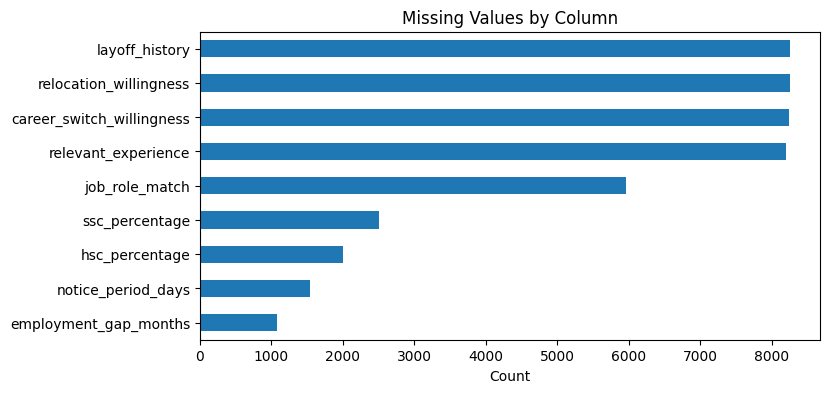

In [18]:
missing = df.isnull().sum()

missing = missing[missing > 0]

plt.figure(figsize=(8,4))
missing.sort_values().plot(kind='barh')
plt.title("Missing Values by Column")
plt.xlabel("Count")
plt.show()

In [6]:
df.duplicated().sum()

np.int64(1376)

In [7]:
df.drop_duplicates(inplace=True)

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df.dtypes

,0
age_years,int64
gender,object
ssc_percentage,float64
hsc_percentage,float64
degree_percentage,float64
degree_specialization,object
technical_score,float64
aptitude_score,float64
communication_score,float64
skills_match_percentage,float64


In [19]:
df.dtypes.value_counts()

,count
object,12
float64,11
int64,3


In [10]:
for col in df.select_dtypes(include="object"):
    print(col)
    print(df[col].unique())
    print("-"*50)

gender
['Male' 'Female' 'female' 'male']
--------------------------------------------------
degree_specialization
['Computer Science' 'Electronics' 'Information Technology' 'Mechanical'
 'Others']
--------------------------------------------------
internship_experience
['No' 'yes ' 'Yes' ' no']
--------------------------------------------------
career_switch_willingness
['Willing' 'Not Willing' nan]
--------------------------------------------------
relevant_experience
['Relevant' 'Not Relevant' nan]
--------------------------------------------------
company_tier
['Tier 3' 'Tier 1' 'Tier 2' 'Tier 2 ' 'Tier 3 ' 'Tier 1 ']
--------------------------------------------------
job_role_match
['Not Matched' 'Matched' nan]
--------------------------------------------------
competition_level
['Medium' 'High' 'Low']
--------------------------------------------------
bond_requirement
['Not Required' 'Required']
--------------------------------------------------
layoff_history
['No' nan 'Yes']
---

In [20]:
print(num_cols)

Index(['age_years', 'ssc_percentage', 'hsc_percentage', 'degree_percentage',
       'technical_score', 'aptitude_score', 'communication_score',
       'skills_match_percentage', 'certifications_count',
       'years_of_experience', 'previous_ctc_lpa', 'expected_ctc_lpa',
       'notice_period_days', 'employment_gap_months'],
      dtype='object')


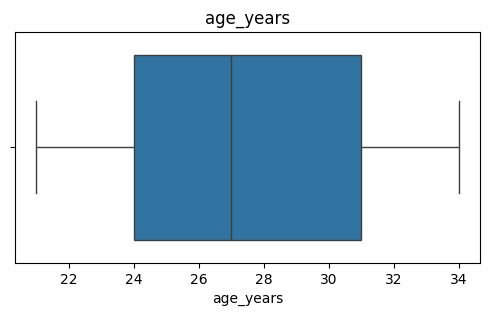

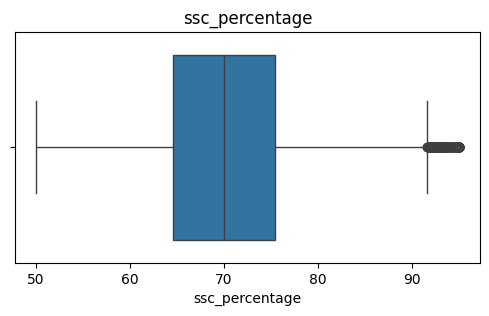

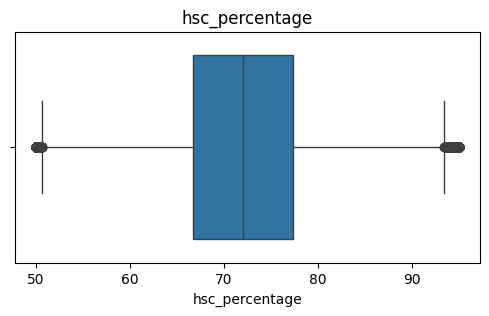

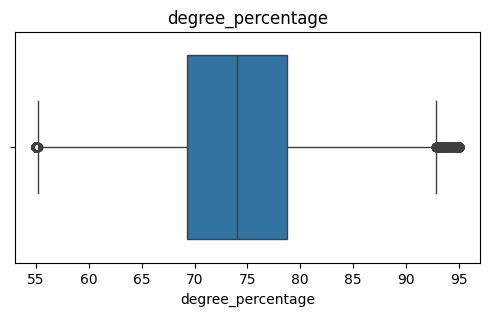

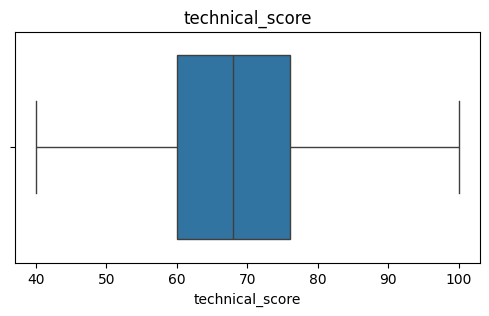

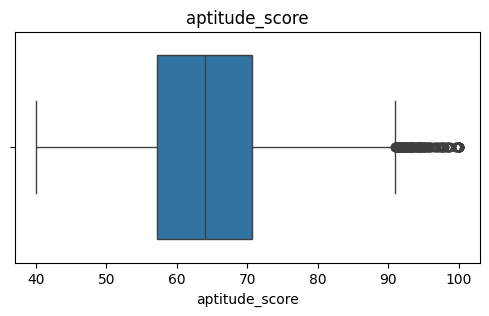

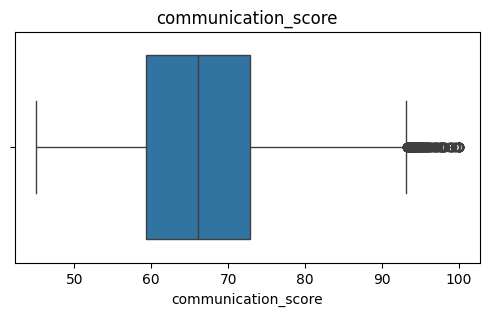

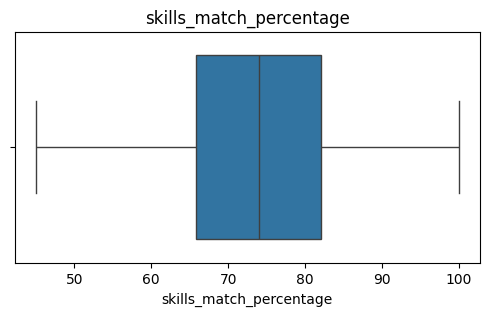

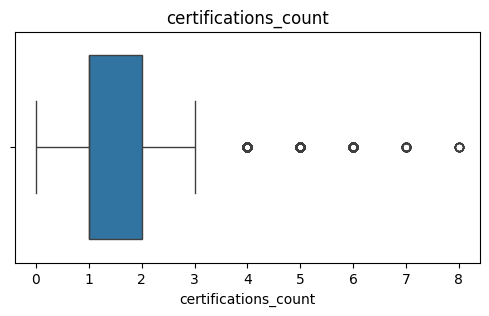

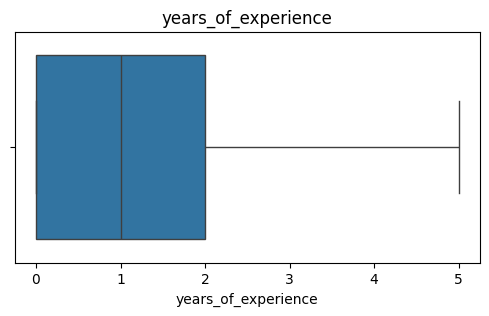

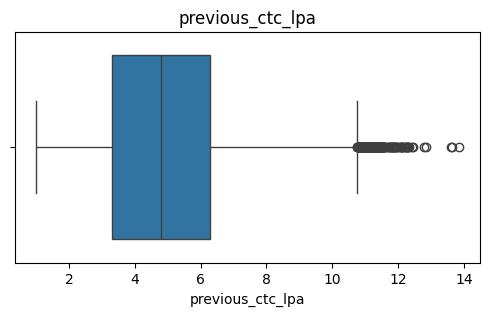

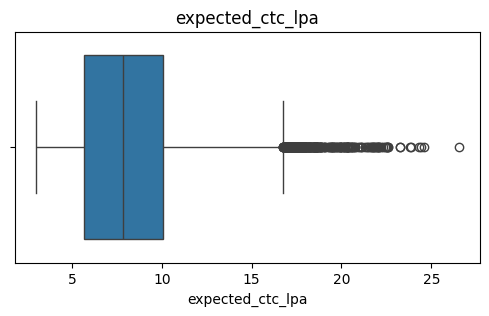

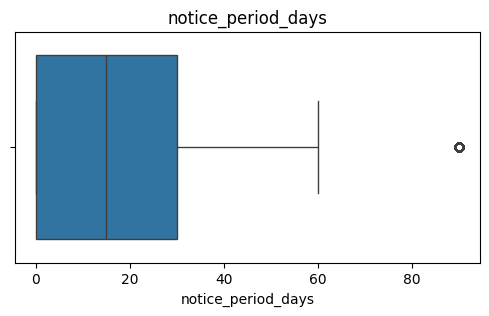

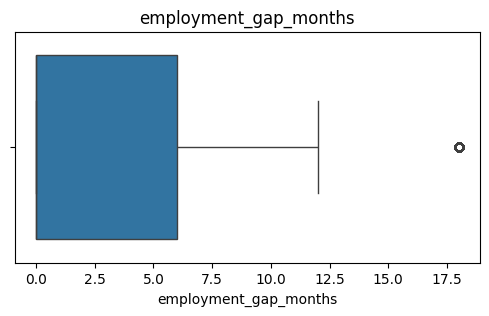

In [11]:
num_cols = df.select_dtypes(include=np.number).columns

for col in num_cols:
    plt.figure(figsize=(6,3))
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.show()

In [14]:
print(df.shape)

(50124, 26)


In [17]:
print("Rows :", df.shape[0])
print("Columns :", df.shape[1])

Rows : 50124
Columns : 26


In [21]:
# Separate numeric and categorical columns
num_cols = df.select_dtypes(include=['number']).columns
cat_cols = df.select_dtypes(include=['object']).columns

# Fill numeric missing values with mean
for col in num_cols:
    df[col].fillna(df[col].mean(), inplace=True)

# Fill categorical missing values with mode
for col in cat_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)

# Verify all missing values are handled
print(df.isnull().sum().sum())

0


In [22]:
df['gender'].value_counts()

,count
gender,
Female,23701
Male,23416
female,1504
male,1503


In [23]:
# Remove leading/trailing spaces from all string columns
for col in df.select_dtypes(include='object'):
    df[col] = df[col].str.strip()

In [24]:
# Gender
df['gender'] = df['gender'].str.title()

# Internship Experience
df['internship_experience'] = df['internship_experience'].str.title()

# Company Tier
df['company_tier'] = df['company_tier'].str.title()

In [25]:
df['gender'].value_counts()

,count
gender,
Female,25205
Male,24919


In [28]:
df['internship_experience'].value_counts()

,count
internship_experience,
No,26216
Yes,23908


In [29]:
df.isnull().sum()

,0
age_years,0
gender,0
ssc_percentage,0
hsc_percentage,0
degree_percentage,0
degree_specialization,0
technical_score,0
aptitude_score,0
communication_score,0
skills_match_percentage,0


In [30]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 50124 entries, 0 to 51497
Data columns (total 26 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   age_years                  50124 non-null  int64  
 1   gender                     50124 non-null  object 
 2   ssc_percentage             50124 non-null  float64
 3   hsc_percentage             50124 non-null  float64
 4   degree_percentage          50124 non-null  float64
 5   degree_specialization      50124 non-null  object 
 6   technical_score            50124 non-null  float64
 7   aptitude_score             50124 non-null  float64
 8   communication_score        50124 non-null  float64
 9   skills_match_percentage    50124 non-null  float64
 10  certifications_count       50124 non-null  int64  
 11  internship_experience      50124 non-null  object 
 12  years_of_experience        50124 non-null  int64  
 13  career_switch_willingness  50124 non-null  object 


In [31]:
df.to_csv("Cleaned_HR_Job_Placement.csv", index=False)

In [32]:
from google.colab import files
files.download("Cleaned_HR_Job_Placement.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>